In [1]:
from myclass import *

In [2]:
#################################################
#------------------ Load Data ------------------#
#################################################

patient_info = pd.read_excel('Dataset.xlsx','patient_information',engine='openpyxl')
cnv_5mb_counts = pd.read_excel('Dataset.xlsx','cnv_5mb_counts',engine='openpyxl').loc[:,['patientID','cnv_Count']].rename(columns={'cnv_Count': 'cnv_Count_5mb'})
cnv_gistic_counts = pd.read_excel('Dataset.xlsx','cnv_gistic_counts',engine='openpyxl').loc[:,['patientID','cnv_Count']].rename(columns={'cnv_Count': 'cnv_Count_gistic'})
snv = pd.read_excel('Dataset.xlsx','snv_feature_matrix',engine='openpyxl')
clinical_info = pd.read_excel('Clinical Feature.xlsx','Supplementary Table 2',engine='openpyxl').drop(['Subject type', 'Subject group', 'Stage (AJCC v7)', 'Pack-years'], axis=1)
clinical_info = clinical_info.rename(columns={'Histology':'Histology label'})

In [3]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"

seed = 1105
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

## Data

In [4]:
##################################################
#-------------- Data Preprocessing -------------#
################################################

#----- Parameters -----#
num_patients_train = len(patient_info[patient_info.split_info == 'training'])# number of patients in training set
num_patients_test = len(patient_info[patient_info.split_info == 'validation'])# number of patients in training set
max_variats = 84 # max number of variation for each patient
num_steps = max_variats
num_feature_not_snv = 8
num_var_attri = snv.shape[1] # number of attributes to discribe each variation
scale = Normalization('MinMaxLogScale') # choose normalizer

#----- OneHot categorical variable of SNV-----#
snv['gene'] = deepcopy(snv['Gene']) # prepare for gene_snv
one_hot,_,_ = OneHotText(snv['Gene'])
snv['Gene'] = [one_hot[i] for i in range(len(one_hot))]

one_hot,_,_ = OneHotText(snv['Variant.type'])
snv['Variant.type'] = [one_hot[i] for i in range(len(one_hot))]
len_feature = {'Variant.type': len(one_hot[0])}

snv['BaseConversion'] = snv['Tumor.allele']+snv['Ref..allele']
one_hot,_,_ = OneHotText(snv['BaseConversion'])
snv['BaseConversion'] = [one_hot[i] for i in range(len(one_hot))]
len_feature['BaseConversion'] = len(one_hot[0])

one_hot,_,_ = OneHotText(snv['Chr'])
snv['Chr'] = [one_hot[i] for i in range(len(one_hot))]
len_feature['Chr'] = len(one_hot[0])

one_hot,_,_ = OneHotText(snv['germline_reads'])
snv['germline_reads'] = [one_hot[i] for i in range(len(one_hot))]
len_feature['germline_reads'] = len(one_hot[0])

# drop coded feature
snv = snv.drop(['Tumor.allele', 'Ref..allele', 'variant', 'lookup', 
                'Case', 'cohort', 'A>CUnstranded', 'A>GUnstranded',
                'A>TUnstranded', 'C>AUnstranded', 'C>GUnstranded', 
                'G>AUnstranded', 'pass_basic_QC', 'blacklist1_oncogenes',
                'pass_basic_QC_coding'], axis=1)

# snv feature list to scale
list_to_normalization = ['Position','Percent.mutant.allele', 'variant_count_norm','ontarget_shoulder_tile_mut_count_norm', 
                         'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p',
                         'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_var_phred_score', 'mean_num_non_ref_bases',
                         'fraction_MapQmin30', 'variant_norm_bc_fam_size', 'normalized_depth','gnomad_maxAF',
                         'size_selected_adjustment','germlinebg_Bayesian_pval', 'cfdnabg_Bayesian_pval',
                         'sum_log10_frag_size_enrich_score', 'germline_depth_at_position', 'cosmic_total_count', 'cosmic_lung_count']

In [5]:
#----- OneHot categorical variable of clinical features ----#
one_hot,_,_ = OneHotText(clinical_info['Sex'])
clinical_info['Sex'] = deepcopy(one_hot)

one_hot,_,_ = OneHotText(clinical_info['Histology label'])
clinical_info['Histology label'] = deepcopy(one_hot)

one_hot,_,_ = OneHotText(clinical_info['Smoker'])
clinical_info['Smoker'] = deepcopy(one_hot)

In [6]:
x = patient_info.set_index('patientID').\
join(cnv_5mb_counts.set_index('patientID')).join(cnv_gistic_counts.set_index('patientID')).drop('SampleID', axis=1).\
join(clinical_info.set_index('Patient ID'))
num_patients = len(x)

In [7]:
#----- snv normalization -----#
snv_group = np.array(snv.drop(['Gene'], axis=1).groupby('patientID'),dtype = object)
list_gene = unique(snv['gene'])
gene_snv_columns = ['Variant.type', 'Chr', 'Position', 'Percent.mutant.allele', 'variant_count_norm',
       'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes',
       'duplex_reads', 'germline_NumNonZeroMeanAF_Pval',
       'mean_bc_family_size', 'watsoncrickfisher.p',
       'mean_total_bc_errors_corrected', 'mean_norm_varpos',
       'mean_var_phred_score', 'mean_num_non_ref_bases',
       'fraction_MapQmin30', 'variant_norm_bc_fam_size',
       'normalized_depth', 'gnomad_maxAF', 'base_change_transition',
       'size_selected_adjustment', 'LUNG_driver',
       'pass_basic_QC_nonsynon_lungdriver',
       'pass_basic_QC_nonsynon_lungdriver_hotspot',
       'germlinebg_Bayesian_pval', 'cfdnabg_Bayesian_pval',
       'sum_log10_frag_size_enrich_score', 'germline_reads',
       'germline_depth_at_position', 'tumor_adjudicated',
       'cosmic_total_count', 'has_matched_tumor',
       'intersect_unpadded_selector', 'cosmic_lung_count',
       'blacklist3tumorsupressor', 'BaseConversion']

zero_snv_feature = []
for i in gene_snv_columns:
    if i in len_feature.keys():
        zero_snv_feature.append([0 for _ in range(len_feature[i])])
    else:
        zero_snv_feature.append(0)
zero_snv_feature = [zero_snv_feature for i in range(len(list_gene))]

x['gene_snv'] = [pd.DataFrame(zero_snv_feature, index=list_gene, columns=gene_snv_columns) for i in range(num_patients)] # fill snv with 0

for i in range(len(snv_group)):
    patient_id = snv_group[i][0]
    # count and check the snv for each gene
    count = Counter(snv_group[i][1]['gene'])
    count = pd.DataFrame(count,index=['frequency']).T
    if any(count['frequency'] > 1):
        gene = count.index[count['frequency'] > 1]
        # reserve the snv with highest 'Percent.mutant.allele'
        for j in range(len(gene)):
            index_repeat_gene = snv_group[i][1]['gene'] == gene[j]
            index_to_drop = argsort(snv_group[i][1][index_repeat_gene]['Percent.mutant.allele']).index[1:]
            snv_group[i][1] = snv_group[i][1].drop(index = index_to_drop)  
    # fill the snv with gene_snv_feature
    gene_snv = snv_group[i][1]['gene']
    gene_snv_feature = snv_group[i][1].drop(['patientID', 'gene'], axis=1)
    x.loc[patient_id,'gene_snv'].loc[gene_snv] = gene_snv_feature.values

x['gene_snv_matrix']= [FlattenSNV(x['gene_snv'][i]) for i in range(num_patients)] 
# x['gene_snv_matrix']= [np.column_stack((FlattenSNV(x['gene_snv'][i]),np.zeros(192))) for i in range(num_patients)]    
snv = snv.drop('gene', axis=1)

In [8]:
##################################################
#-------------- Obtain Training Set -------------#
################################################
train_x = deepcopy(x[x.split_info == 'training'])

#----- clinical features normalization -----#
clinical_list_to_normalization = ['Age (years)', 'Plasma volume used', 'Plasma cfDNA concentration (ng/mL)', 'Plasma DNA input (ng)']
train_x = normalizer(train_x, clinical_list_to_normalization, scale)
#----- cnv normalization -----#
cnv_list_to_normalization = ['cnv_Count_5mb','cnv_Count_gistic']
train_x = normalizer(train_x, cnv_list_to_normalization, scale)
#----- snv normalization -----#
train_snv = deepcopy(snv[['SU2'not in i for i in snv['patientID']]])
train_snv = normalizer(train_snv, list_to_normalization, scale)
train_x = GroupAndExtractSNV(train_x, train_snv, num_steps)
    
#----- Label -----#    
train_x['label'] = [1 if 'LUP' in train_x.index[i] else 0 for i in range(train_x.shape[0])]
one_hot,_,_ = OneHotText(train_x['Stage_group'])
train_x['stage_label'] = [one_hot[i] for i in range(len(one_hot))]
train_x = train_x.drop(['Stage_group'], axis=1)

# # x.to_excel("preprocessed_training_dataset.xlsx")     

In [9]:
##################################################
#-------------- Obtain Test Set -------------#
################################################

test_x = deepcopy(x[x.split_info == 'validation'])

#----- clinical features normalization -----#
test_x = normalizer(test_x, clinical_list_to_normalization, scale)
#----- cnv normalization -----#
test_x = normalizer(test_x, cnv_list_to_normalization, scale)
#----- snv normalization -----#
test_snv = deepcopy(snv[['SU2' in i for i in snv['patientID']]])
test_snv = normalizer(test_snv, list_to_normalization, scale)
test_x = GroupAndExtractSNV(test_x, test_snv, num_steps)
    
#----- Label -----#    
test_x['label'] = [1 if 'SU2CS' in test_x.index[i] else 0 for i in range(test_x.shape[0])]
one_hot,_,_ = OneHotText(test_x['Stage_group'])
test_x['stage_label'] = [one_hot[i] for i in range(len(one_hot))]
test_x = test_x.drop(['Stage_group'], axis=1)
    
# # x.to_excel("preprocessed_testing_dataset.xlsx")     

In [10]:
train_x_org = deepcopy(train_x)
test_x_org = deepcopy(test_x)

In [11]:
train_x.head()

,split_info,cnv_Count_5mb,cnv_Count_gistic,Age (years),Sex,Histology label,Smoker,Plasma volume used,Plasma cfDNA concentration (ng/mL),Plasma DNA input (ng),gene_snv,gene_snv_matrix,snv,snv_valid_len,label,stage_label
patientID,,,,,,,,,,,,,,,,
LDCT01,training,0.261036,0.89868,0.703616,0.0,1.0,0.0,0.665951,0.409219,0.860456,Variant.type \ ACAN [...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.0,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
LDCT02,training,0.391554,0.00000,0.622569,1.0,1.0,0.0,0.669747,0.425257,0.891758,Variant.type \ ACAN [...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",3.0,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
LDCT03,training,0.321000,0.00000,0.870218,0.0,1.0,0.0,0.503102,0.574742,0.892360,Variant.type \ ACAN [...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.0,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
LDCT04,training,0.172535,0.89868,0.742419,1.0,1.0,0.0,0.609554,0.479491,0.892360,Variant.type \ ACAN [...,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1.0,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
LDCT05,training,0.402969,0.00000,0.683797,0.0,1.0,0.0,0.482308,0.578380,0.868251,Variant.type \ ACAN [...,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0.0,0,"[1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]"


# AutoML based on Baysian optimization

In [12]:
class MLP(nn.Module):
    """
    Class description: only Dropout on LSTM & FC no batch norm, bidirectional Long Short-term memory model
    
    """
    #----- Define all layers -----#
    def __init__(self, fc_dropout, num_feature_not_snv, num_output_nodes, num_fc_layers, device, input_shape, act = nn.Sigmoid(), **kwargs):
        super(MLP, self).__init__(**kwargs)
        len_sentence, feature_dim = input_shape[0], input_shape[1]
        #--- Fully connected layers ---#
        self.input2model = nn.Linear(feature_dim, 1)    
        self.num_fc_layers = num_fc_layers
        num_fc_input =  num_feature_not_snv+len_sentence
        if num_fc_layers == 1:
            self.fc0 = nn.Linear(num_fc_input, num_output_nodes)
        else:
            # the first fc layer
            self.fc0 = nn.Linear(num_fc_input, int(ceil(num_fc_input/2)))
            self.dropout0 = nn.Dropout(1.1*fc_dropout)
            if num_fc_layers == 2:
                # the last fc layer when num_fc_layers == 2
                self.fc1 = nn.Linear(int(ceil(num_fc_input/2)), num_output_nodes)
            else:
                # the middle fc layer
                for i in range(1,num_fc_layers-1):
                    tmp_input = int(ceil(num_fc_input/2**i))
                    tmp_output = int(ceil(num_fc_input/2**(i+1)))
                    exec('self.fc{} = nn.Linear(tmp_input, tmp_output)'.format(i))
                    if i < ceil(num_fc_layers/2) and 1.1**(i+1)*fc_dropout < 1:
                        exec('self.dropout{} = nn.Dropout(1.1**(i+1)*fc_dropout)'.format(i))
                    elif i >= ceil(num_fc_layers/2) and 1.1**(num_fc_layers-1-i)*fc_dropout < 1:
                        exec('self.dropout{} = nn.Dropout(1.1**(num_fc_layers-1-i)*fc_dropout)'.format(i))
                    else:
                        exec('self.dropout{} = nn.Dropout(0.5)'.format(i))
                # the last fc layer
                exec('self.fc{} = nn.Linear(tmp_output, num_output_nodes)'.format(i+1))
            
        #--- Activation function ---#
        self.act = act
    
    #----- Forward -----#
    def forward(self, x_snv, x_other):
        
        # x_snv size: [batch size, num_gene, feature_dim]
        
        #--- Transformer layer ---#
        output = torch.squeeze(self.input2model(x_snv))
        
        #--- Fully connected layers ---#
        #--- Joins the final forward and reverse hidden states ---#
        hidden_dense = torch.cat((x_other, output), dim = 1)
        if self.num_fc_layers == 1:
            outputs = self.fc0(hidden_dense)
        else:
            # the first fc layer
            outputs = self.act(self.dropout0(self.fc0(hidden_dense)))
            if self.num_fc_layers == 2:
                # the last fc layer when num_fc_layers == 2
                outputs = self.fc1(outputs)
            else:
                # the middle fc layer
                for i in range(1,self.num_fc_layers-1):
                    outputs = eval('self.act(self.dropout{}(self.fc{}(outputs)))'.format(i,i))
                # the last fc layer
                outputs = eval('self.fc{}(outputs)'.format(i+1))
            
        return outputs.softmax(dim=1)

In [13]:
def train_val_test(fc_dropout, num_feature_not_snv, num_fc_layers, batch_size, lr, patience, num_outer_split, frac_inner_val, train_x, num_epochs, device):
    shape = train_x['snv'][0].shape
    train_kf = []
    val_kf = []
    test_kf = []
    KF = StratifiedKFold(num_outer_split, shuffle=True)
    for train_index, sub_test_index in KF.split(train_x, train_x['label']):
        sub_train_index, sub_val_index = next(StratifiedShuffleSplit(n_splits=1,test_size=frac_inner_val).
                                               split(train_x.iloc[train_index],train_x.iloc[train_index]['label']))

        #---  Seperate traing set, validation set and test set ---#
        sub_train = Resampler(train_x.iloc[sub_train_index][:], train_x.iloc[sub_train_index]['label'])
        train_iter = BatchDataGeneration(sub_train, batch_size, shuffle=True)
        val_iter = BatchDataGeneration(train_x.iloc[sub_val_index][:], batch_size, shuffle=True)
        test_iter = BatchDataGeneration(train_x.iloc[sub_test_index][:], batch_size, shuffle=True)


        #-----  Instantiate model -----#
        # setting 'lstm_bidirectional=True'to define Bidirectional LSTM model
        model = MLP(fc_dropout, num_feature_not_snv, num_output_nodes, num_fc_layers, device, shape)
        model = model.to(device)

        model.apply(init_weights)

        #-----  Loss -----#
        loss = nn.CrossEntropyLoss(reduction="none")
        loss = loss.to(device)

        #--- Define optimizer ---#
        optimizer = torch.optim.Adam(model.parameters(), lr)
        
        #-----  Instantiate EarlyStopping -----#
        early_stopping = EarlyStopping(patience, verbose=False)

        train_loss, train_acc, train_auc, train_speed, val_loss, val_acc, val_auc = train_evaluate(
            model, train_iter, val_iter, loss, optimizer, early_stopping, num_epochs, device)
        
        model.eval()
        test_loss, test_acc, test_auc = evaluate(model, test_iter, loss, device)
        train_kf.append([train_loss, train_acc, train_auc, train_speed])
        val_kf.append([val_loss, val_acc, val_auc])
        test_kf.append([test_loss, test_acc, test_auc])
    return train_kf, val_kf, test_kf

In [14]:
# ---------------------------------------------------#   
#    Parameter Tuning with Bayesian optimization    #
#--------------------------------------------------# 
num_outer_split = 5
frac_inner_val = 0.25
num_output_nodes, num_epochs = 2, 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


lstm_bidirectional = True
best_score = 100
batch_size = 64
snv_to_select = snv.drop('patientID', axis=1).columns
other_feature_to_select = train_x.drop(['split_info', 'Histology label', 'label', 'stage_label', 'snv','gene_snv','gene_snv_matrix'], axis=1).columns
num_feature_to_select = len(snv_to_select) + len(other_feature_to_select)



##---   Define search space   ---##
# The list of hyper-parameters we want to optimize. For each one we define the
# bounds, the corresponding parameter name, as well as how to
# sample values from that dimension (`'log-uniform'` for the learning rate)

search_spaces = [Integer(1,2**10-1, name = 'ten_int_selected_features'),
                 Integer(1,2**10-1, name = 'twenty_int_selected_features'),
                 Integer(1,2**10-1, name = 'thirty_int_selected_features'),
                 Integer(1,2**7-1, name = 'thirty_seven_selected_features'),
                 Integer(1,2**9-1, name = 'forty_six_int_selected_features'),
                 Real(1e-1, 0.5, prior='log-uniform', name = 'fc_dropout'),
                 Real(1e-3, 1e-1, prior='log-uniform', name = 'lr'),
                 Integer(1,10, name = 'patience'),
                 Integer(1,10, name = 'num_fc_layers')
                ]

@use_named_args(search_spaces)
def masked_objective(ten_int_selected_features, twenty_int_selected_features, thirty_int_selected_features, thirty_seven_selected_features,
                     forty_six_int_selected_features, fc_dropout, lr, patience, num_fc_layers):
    global best_score, snv_to_select, other_feature_to_select
#     print(num_feature_to_select)
    #---   Decoding feature selection results   ---#
    bin_selected_features = bin(ten_int_selected_features)[2:]
    for i in range(10-len(bin_selected_features)):
        bin_selected_features = '0' + bin_selected_features
        
    tmp_bin_selected_features = bin(twenty_int_selected_features)[2:]
    for i in range(10-len(tmp_bin_selected_features)):
        tmp_bin_selected_features = '0' + tmp_bin_selected_features
    bin_selected_features = bin_selected_features+ tmp_bin_selected_features
    
    tmp_bin_selected_features = bin(thirty_int_selected_features)[2:]
    for i in range(10-len(tmp_bin_selected_features)):
        tmp_bin_selected_features = '0' + tmp_bin_selected_features
    bin_selected_features = bin_selected_features+ tmp_bin_selected_features
    
    tmp_bin_selected_features = bin(thirty_seven_selected_features)[2:]
    for i in range(7-len(tmp_bin_selected_features)):
        tmp_bin_selected_features = '0' + tmp_bin_selected_features
    bin_selected_features = bin_selected_features+ tmp_bin_selected_features

#     print(len(bin_selected_features))
#     print(len(snv_to_select))
#     print(snv_to_select)
    
    snv_selected = [snv_to_select[i] for i in range(len(snv_to_select)) if bin_selected_features[i] == '1']
    snv_selected.append('patientID')
    
    
    
    bin_selected_features = bin(forty_six_int_selected_features)[2:]
    for i in range(9-len(bin_selected_features)):
        bin_selected_features = '0' + bin_selected_features
        
    
    other_feature_selected = [other_feature_to_select[i] for i in range(len(other_feature_to_select)) if bin_selected_features[i] == '1']
    other_feature_selected.append('label')
    
    new_train_snv = deepcopy(train_snv[snv_selected])
    new_train_x = deepcopy(train_x[other_feature_selected])
    new_train_x = NewGroupAndExtractSNV(new_train_x, new_train_snv, num_steps)
    
    num_inputs_lstm = new_train_x.iloc[0]['snv'].shape[1]
    
    num_feature_not_snv = len(other_feature_selected)-1
    
    train_all, val_all, test_all = train_val_test(fc_dropout, num_feature_not_snv, num_fc_layers, batch_size, lr, patience,
                                                  num_outer_split, frac_inner_val, new_train_x, num_epochs, device)
        
    train_all = np.array(train_all)
    val_all = np.array(val_all)
    test_all = np.array(test_all)
    train_loss, train_acc, train_auc, train_speed = train_all[:,0], train_all[:,1], train_all[:,2], train_all[:,3]
    val_loss, val_acc, val_auc = val_all[:,0], val_all[:,1], val_all[:,2]
    test_loss, test_acc, test_auc = test_all[:,0], test_all[:,1], test_all[:,2]    
    print('-'*20)
    print('One layer without smote without mask with early stopping under k-fold cv best model:')
    print('-'*20)
    print(f'On training set: Loss {train_loss.mean():.3f}, Accuracy {train_acc.mean():.3f}, Auc {train_auc.mean():.3f}, {train_speed.mean():.1f} samples/s {str(device)}.')
    print(f'On validation set: Loss {val_loss.mean():.3f}, Accuracy {val_acc.mean():.3f}, Auc {val_auc.mean():.3f}.')
    print(f'On test set: Loss {test_loss.mean():.3f}, Accuracy {test_acc.mean():.3f}, Auc {test_auc.mean():.3f}.')
    
    train_score = -train_auc.mean()
    val_score = -val_auc.mean()
    test_score = -test_auc.mean()
    
    tmp = val_score+test_score
    
    if tmp < best_score:
        best_score = tmp
        best_score = val_score
        print('*'*20)
        print("""Best parameters:
        snv_selected = %s
        other_feature_selected = %s
        fc_dropout = %f
        lr = %f
        patience = %d
        num_fc_layers = %d
        """ % (snv_selected, other_feature_selected, fc_dropout, lr, patience, num_fc_layers))
        print('*'*20)
    else:
        print("""Current parameters:
        snv_selected = %s
        other_feature_selected = %s
        fc_dropout = %f
        lr = %f
        patience = %d
        num_fc_layers = %d
        """ % (snv_selected, other_feature_selected, fc_dropout, lr, patience, num_fc_layers))
        
    frac_feature = 0.05*(len(other_feature_selected) - 1)/ len(other_feature_to_select)+ 0.01*len(snv_selected)/len(snv_to_select)

    return (0.5*tmp + frac_feature)


In [15]:
t = time.localtime()
print(str(t.tm_hour)+':'+str(t.tm_min))

9:10


Iteration No: 1 started. Evaluating function at random point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.701, Accuracy 0.502, Auc 0.516, 1924.1 samples/s cuda.
On validation set: Loss 0.681, Accuracy 0.644, Auc 0.754.
On test set: Loss 0.679, Accuracy 0.656, Auc 0.792.
********************
Best parameters:
        snv_selected = ['Gene', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p', 'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_num_non_ref_bases', 'normalized_depth', 'gnomad_maxAF', 'size_selected_adjustment', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'sum_log10_frag_size_enrich_score', 'germline_reads', 'tumor_adjudicated', 'cosmic_total_count', 'intersect_unpadded_selector', 'blacklist3tumorsupressor', 'BaseConversio

--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.692, Accuracy 0.485, Auc 0.547, 1599.5 samples/s cuda.
On validation set: Loss 0.692, Accuracy 0.550, Auc 0.682.
On test set: Loss 0.689, Accuracy 0.650, Auc 0.697.
********************
Best parameters:
        snv_selected = ['Gene', 'Percent.mutant.allele', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p', 'mean_norm_varpos', 'mean_var_phred_score', 'mean_num_non_ref_bases', 'fraction_MapQmin30', 'normalized_depth', 'gnomad_maxAF', 'base_change_transition', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'germlinebg_Bayesian_pval', 'germline_reads', 'tumor_adjudicated', 'cosmic_total_count', 'intersect_unpadded_selector', 'cosmic_lung_count', 'patientID']
        other_feature_selected = ['Plasma cfDNA concentration (ng/mL)', 'Plasma DNA input (ng

Iteration No: 14 ended. Search finished for the next optimal point.
Time taken: 10.7631
Function value obtained: -0.8289
Current minimum: -0.8780
Iteration No: 15 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.471, Accuracy 0.850, Auc 0.864, 1987.2 samples/s cuda.
On validation set: Loss 0.615, Accuracy 0.694, Auc 0.791.
On test set: Loss 0.479, Accuracy 0.844, Auc 0.921.
********************
Best parameters:
        snv_selected = ['Variant.type', 'Chr', 'Position', 'Gene', 'Percent.mutant.allele', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'mean_var_phred_score', 'normalized_depth', 'gnomad_maxAF', 'base_change_transition', 'size_selected_adjustment', 'LUNG_driver', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon

Iteration No: 20 ended. Search finished for the next optimal point.
Time taken: 12.4929
Function value obtained: -0.8372
Current minimum: -0.8780
Iteration No: 21 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.403, Accuracy 0.922, Auc 0.942, 2133.1 samples/s cuda.
On validation set: Loss 0.567, Accuracy 0.738, Auc 0.848.
On test set: Loss 0.456, Accuracy 0.856, Auc 0.926.
********************
Best parameters:
        snv_selected = ['Variant.type', 'Chr', 'Position', 'Gene', 'Percent.mutant.allele', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'germline_NumNonZeroMeanAF_Pval', 'mean_bc_family_size', 'watsoncrickfisher.p', 'mean_total_bc_errors_corrected', 'mean_norm_varpos', 'mean_var_phred_score', 'mean_num_non_ref_bases', 'fraction_MapQmin30', 'variant_norm_bc_fam_size', 'normalized_

--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.471, Accuracy 0.858, Auc 0.889, 2830.3 samples/s cuda.
On validation set: Loss 0.527, Accuracy 0.794, Auc 0.866.
On test set: Loss 0.493, Accuracy 0.806, Auc 0.883.
********************
Best parameters:
        snv_selected = ['Position', 'Percent.mutant.allele', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'watsoncrickfisher.p', 'mean_norm_varpos', 'mean_num_non_ref_bases', 'fraction_MapQmin30', 'variant_norm_bc_fam_size', 'gnomad_maxAF', 'base_change_transition', 'size_selected_adjustment', 'LUNG_driver', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'sum_log10_frag_size_enrich_score', 'germline_depth_at_position', 'cosmic_total_count', 'has_matched_tumor', 'cosmic_lung_count', 'blacklist3tumorsupressor', 'BaseConversion', 'patientID']
        othe

...

Iteration No: 73 ended. Search finished for the next optimal point.
Time taken: 9.9882
Function value obtained: -0.8404
Current minimum: -0.9126
Iteration No: 74 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.664, Accuracy 0.552, Auc 0.573, 2052.7 samples/s cuda.
On validation set: Loss 0.654, Accuracy 0.569, Auc 0.744.
On test set: Loss 0.690, Accuracy 0.594, Auc 0.765.
********************
Best parameters:
        snv_selected = ['Variant.type', 'Chr', 'Position', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'duplex_reads', 'gnomad_maxAF', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'cfdnabg_Bayesian_pval', 'sum_log10_frag_size_enrich_score', 'germline_reads', 'tumor_adjudicated', 'cosmic_total_count', 'has_matched_tumor', 'intersect_unpadded_selector', 'cosmic_lung_count', 'blacklist3tumorsupressor', 'BaseConversion

Iteration No: 80 ended. Search finished for the next optimal point.
Time taken: 8.3276
Function value obtained: -0.8498
Current minimum: -0.9126
Iteration No: 81 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.549, Accuracy 0.789, Auc 0.877, 2687.6 samples/s cuda.
On validation set: Loss 0.567, Accuracy 0.775, Auc 0.852.
On test set: Loss 0.547, Accuracy 0.775, Auc 0.869.
********************
Best parameters:
        snv_selected = ['Chr', 'Position', 'Gene', 'variant_count_norm', 'pass_split_1yes', 'duplex_reads', 'gnomad_maxAF', 'base_change_transition', 'size_selected_adjustment', 'LUNG_driver', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'germlinebg_Bayesian_pval', 'cfdnabg_Bayesian_pval', 'sum_log10_frag_size_enrich_score', 'germline_reads', 'germline_depth_at_position', 'tumor_adjudicated', 'cos

--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.452, Accuracy 0.858, Auc 0.902, 2845.1 samples/s cuda.
On validation set: Loss 0.542, Accuracy 0.769, Auc 0.872.
On test set: Loss 0.468, Accuracy 0.850, Auc 0.884.
********************
Best parameters:
        snv_selected = ['Variant.type', 'duplex_reads', 'gnomad_maxAF', 'size_selected_adjustment', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'germlinebg_Bayesian_pval', 'sum_log10_frag_size_enrich_score', 'germline_reads', 'tumor_adjudicated', 'cosmic_total_count', 'has_matched_tumor', 'intersect_unpadded_selector', 'cosmic_lung_count', 'blacklist3tumorsupressor', 'BaseConversion', 'patientID']
        other_feature_selected = ['Age (years)', 'Sex', 'Smoker', 'Plasma cfDNA concentration (ng/mL)', 'snv_valid_len', 'label']
        fc_dropout = 0.151461
        lr = 0.014001
        patience = 10
   

Iteration No: 92 ended. Search finished for the next optimal point.
Time taken: 20.5528
Function value obtained: -0.8211
Current minimum: -0.9126
Iteration No: 93 started. Searching for the next optimal point.
--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.529, Accuracy 0.786, Auc 0.794, 2138.6 samples/s cuda.
On validation set: Loss 0.541, Accuracy 0.775, Auc 0.875.
On test set: Loss 0.520, Accuracy 0.806, Auc 0.868.
********************
Best parameters:
        snv_selected = ['Variant.type', 'Chr', 'Position', 'Percent.mutant.allele', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'duplex_reads', 'mean_bc_family_size', 'mean_var_phred_score', 'fraction_MapQmin30', 'normalized_depth', 'base_change_transition', 'size_selected_adjustment', 'LUNG_driver', 'pass_basic_QC_nonsynon_lungdriver', 'pass_basic_QC_nonsynon_lungdriver_hotspot', 'germlinebg_Bayesian_pval', 'cfdn

--------------------
One layer without smote without mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.448, Accuracy 0.891, Auc 0.925, 2265.7 samples/s cuda.
On validation set: Loss 0.591, Accuracy 0.681, Auc 0.806.
On test set: Loss 0.474, Accuracy 0.844, Auc 0.919.
********************
Best parameters:
        snv_selected = ['Position', 'Gene', 'variant_count_norm', 'ontarget_shoulder_tile_mut_count_norm', 'pass_split_1yes', 'duplex_reads', 'gnomad_maxAF', 'germline_depth_at_position', 'BaseConversion', 'patientID']
        other_feature_selected = ['Sex', 'Smoker', 'label']
        fc_dropout = 0.100000
        lr = 0.013210
        patience = 10
        num_fc_layers = 4
        
********************
Iteration No: 99 ended. Search finished for the next optimal point.
Time taken: 12.0726
Function value obtained: -0.8482
Current minimum: -0.9126
Iteration No: 100 started. Searching for the next optimal point.
--------------------
One l

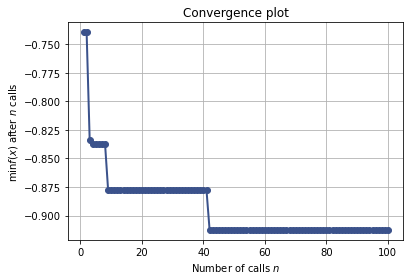

In [16]:
masked_gp = gp_minimize(masked_objective, search_spaces, n_calls=100, random_state=920,acq_func="EI",verbose=True, n_jobs=-1)

"Best score=%.4f" % masked_gp.fun

#---   Decoding feature selection results   ---#
bin_selected_features = bin(masked_gp.x[0])[2:]
for i in range(10-len(bin_selected_features)):
    bin_selected_features = '0' + bin_selected_features

tmp_bin_selected_features = bin(masked_gp.x[1])[2:]
for i in range(10-len(tmp_bin_selected_features)):
    tmp_bin_selected_features = '0' + tmp_bin_selected_features
bin_selected_features = bin_selected_features+ tmp_bin_selected_features

tmp_bin_selected_features = bin(masked_gp.x[2])[2:]
for i in range(10-len(tmp_bin_selected_features)):
    tmp_bin_selected_features = '0' + tmp_bin_selected_features
bin_selected_features = bin_selected_features+ tmp_bin_selected_features

tmp_bin_selected_features = bin(masked_gp.x[3])[2:]
for i in range(7-len(tmp_bin_selected_features)):
    tmp_bin_selected_features = '0' + tmp_bin_selected_features
bin_selected_features = bin_selected_features+ tmp_bin_selected_features

snv_selected = [snv_to_select[i] for i in range(len(snv_to_select)) if bin_selected_features[i] == '1']
#     print(snv_selected)
#     if snv_selected == []:
#         snv_selected = ['Gene']
snv_selected.append('patientID')

bin_selected_features = bin(masked_gp.x[4])[2:]
for i in range(9-len(bin_selected_features)):
    bin_selected_features = '0' + bin_selected_features


other_feature_selected = [other_feature_to_select[i] for i in range(len(other_feature_to_select)) if bin_selected_features[i] == '1']
other_feature_selected.append('label')
##---   Print parameters   ---##
print("""Best parameters:
        snv_selected = %s
        other_feature_selected = %s
        fc_dropout = %f
        lr = %f
        patience = %d
        num_fc_layers = %d""" % (snv_selected, other_feature_selected, masked_gp.x[5],masked_gp.x[6], masked_gp.x[7],
                    masked_gp.x[8]))

from skopt.plots import plot_convergence


fig = plt.figure()

ax1=plot_convergence(masked_gp)
plt.savefig(str(t.tm_mon)+'-'+str(t.tm_mday)+'-'+str(t.tm_hour)+'AutoMLP.png')
plt.savefig(str(t.tm_mon)+'-'+str(t.tm_mday)+'-'+str(t.tm_hour)+'AutoMLP.eps')

In [18]:
# ---------------------------------------------------#   
#    Parameter Tuning with Bayesian optimization    #
#--------------------------------------------------# 
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

seed = 1105

num_outer_split = 5
num_output_nodes, num_epochs = 2, 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
fc_dropout, lr, patience, num_fc_layers = masked_gp.x[5],masked_gp.x[6], masked_gp.x[7], masked_gp.x[8]

new_train_snv = deepcopy(train_snv[snv_selected])
new_train_x = deepcopy(train_x[other_feature_selected])
new_train_x = NewGroupAndExtractSNV(new_train_x, new_train_snv, num_steps)

new_test_snv = deepcopy(test_snv[snv_selected])
new_test_x = deepcopy(test_x[other_feature_selected])
new_test_x = NewGroupAndExtractSNV(new_test_x, new_test_snv, num_steps)

num_inputs_lstm = new_train_x.iloc[0]['snv'].shape[1]
num_feature_not_snv = len(other_feature_selected)-1
shape = new_train_x['snv'][0].shape

num_repeat = 100
frac_val = 0.25
train_all = []
val_all = []

test_all = []
for i in range(num_repeat):
    seed = seed + i
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)    
    
    sub_train_index, sub_val_index = next(StratifiedShuffleSplit(n_splits=1,test_size=frac_val).split(new_train_x,new_train_x['label']))

    #---  Seperate traing set, validation set and test set ---#
    sub_train = Resampler(new_train_x.iloc[sub_train_index][:], new_train_x.iloc[sub_train_index]['label'])
    train_iter = BatchDataGeneration(sub_train, batch_size, shuffle=True)
    val_iter = BatchDataGeneration(new_train_x.iloc[sub_val_index][:], batch_size, shuffle=True)
    test_iter = BatchDataGeneration(new_test_x, batch_size, shuffle=True)
    
    
    
    #-----  Instantiate model -----#
    model = MLP(fc_dropout, num_feature_not_snv, num_output_nodes, num_fc_layers, device, shape)
    model = model.to(device)
    model.apply(init_weights)
    
    #-----  Loss -----#
    loss = nn.CrossEntropyLoss(reduction="none")
    loss = loss.to(device)

    #--- Define optimizer ---#
    optimizer = torch.optim.Adam(model.parameters(), lr)

    #-----  Instantiate EarlyStopping -----#
    early_stopping = EarlyStopping(patience, verbose=False)

    train_loss, train_acc, train_auc, train_speed, val_loss, val_acc, val_auc = train_evaluate(
        model, train_iter, val_iter, loss, optimizer, early_stopping, num_epochs, device)

    test_loss, test_acc, test_auc = evaluate(model, test_iter, loss, device)

    train_all.append([train_loss, train_acc, train_auc, train_speed])
    val_all.append([val_loss, val_acc, val_auc])
    test_all.append([test_loss, test_acc, test_auc])
    print('-'*20)
    print('num of repeat:', i)
    print('-'*20)
    print(f'On training set: Loss {train_loss:.3f}, Accuracy {train_acc:.3f}, Auc {train_auc:.3f}, {train_speed:.1f} samples/s {str(device)}.')
    print(f'On validation set: Loss {val_loss:.3f}, Accuracy {val_acc:.3f}, Auc {val_auc:.3f}.')
    print(f'On test set: Loss {test_loss:.3f}, Accuracy {test_acc:.3f}, Auc {test_auc:.3f}.')


train_all = np.array(train_all)
val_all = np.array(val_all)
test_all = np.array(test_all)

train_loss, train_acc, train_auc, train_speed = train_all[:,0], train_all[:,1], train_all[:,2], train_all[:,3]
val_loss, val_acc, val_auc = val_all[:,0], val_all[:,1], val_all[:,2]
test_loss, test_acc, test_auc = test_all[:,0], test_all[:,1], test_all[:,2]    
print('-'*20)
print('One layer without smote with mask with early stopping under k-fold cv best model:')
print('-'*20)
print(f'On training set: Loss {train_loss.mean():.3f}, Accuracy {train_acc.mean():.3f}, Auc {train_auc.mean():.3f}, {train_speed.mean():.1f} samples/s {str(device)}.')
print(f'On validation set: Loss {val_loss.mean():.3f}, Accuracy {val_acc.mean():.3f}, Auc {val_auc.mean():.3f}.')
print(f'On test set: Loss {test_loss.mean():.3f}, Accuracy {test_acc.mean():.3f}, Auc {test_auc.mean():.3f}.')

#-----  Save performance -----#
df = (('train_loss', 'train_acc', 'train_auc', 'train_speed', 'val_loss', 'val_acc', 'val_auc', 'test_loss', 'test_acc', 'test_auc'),  
      (train_loss, train_acc, train_auc, train_speed, val_loss, val_acc, val_auc, test_loss, test_acc, test_auc)  
      )
df = pd.DataFrame(df)
t = time.localtime()

file_name = 'AutoMLP'+str(t.tm_year)+'-'+str(t.tm_mon)+'-'+str(t.tm_mday)+'-'+str(t.tm_hour)+'-'+str(t.tm_min)+'.xlsx' #(t.tm_year)

df.to_excel(file_name,index = False)

--------------------
num of repeat: 0
--------------------
On training set: Loss 0.390, Accuracy 0.962, Auc 0.957, 1885.0 samples/s cuda.
On validation set: Loss 0.535, Accuracy 0.775, Auc 0.857.
On test set: Loss 0.550, Accuracy 0.766, Auc 0.800.
--------------------
num of repeat: 1
--------------------
On training set: Loss 0.373, Accuracy 0.955, Auc 0.967, 1777.9 samples/s cuda.
On validation set: Loss 0.522, Accuracy 0.800, Auc 0.890.
On test set: Loss 0.687, Accuracy 0.617, Auc 0.657.
--------------------
num of repeat: 2
--------------------
On training set: Loss 0.390, Accuracy 0.942, Auc 0.962, 1908.0 samples/s cuda.
On validation set: Loss 0.527, Accuracy 0.800, Auc 0.835.
On test set: Loss 0.697, Accuracy 0.606, Auc 0.660.
--------------------
num of repeat: 3
--------------------
On training set: Loss 0.382, Accuracy 0.949, Auc 0.955, 2031.9 samples/s cuda.
On validation set: Loss 0.438, Accuracy 0.875, Auc 0.978.
On test set: Loss 0.614, Accuracy 0.691, Auc 0.793.
--------

--------------------
num of repeat: 33
--------------------
On training set: Loss 0.371, Accuracy 0.955, Auc 0.944, 2370.5 samples/s cuda.
On validation set: Loss 0.523, Accuracy 0.775, Auc 0.918.
On test set: Loss 0.631, Accuracy 0.681, Auc 0.774.
--------------------
num of repeat: 34
--------------------
On training set: Loss 0.359, Accuracy 0.981, Auc 0.971, 2114.2 samples/s cuda.
On validation set: Loss 0.615, Accuracy 0.700, Auc 0.816.
On test set: Loss 0.647, Accuracy 0.670, Auc 0.690.
--------------------
num of repeat: 35
--------------------
On training set: Loss 0.355, Accuracy 0.981, Auc 0.988, 2086.0 samples/s cuda.
On validation set: Loss 0.541, Accuracy 0.775, Auc 0.898.
On test set: Loss 0.584, Accuracy 0.734, Auc 0.772.
--------------------
num of repeat: 36
--------------------
On training set: Loss 0.400, Accuracy 0.929, Auc 0.921, 2114.2 samples/s cuda.
On validation set: Loss 0.592, Accuracy 0.725, Auc 0.860.
On test set: Loss 0.649, Accuracy 0.660, Auc 0.707.
----

--------------------
num of repeat: 66
--------------------
On training set: Loss 0.368, Accuracy 0.962, Auc 0.957, 2058.6 samples/s cuda.
On validation set: Loss 0.541, Accuracy 0.775, Auc 0.871.
On test set: Loss 0.584, Accuracy 0.723, Auc 0.791.
--------------------
num of repeat: 67
--------------------
On training set: Loss 0.374, Accuracy 0.949, Auc 0.948, 2086.0 samples/s cuda.
On validation set: Loss 0.564, Accuracy 0.750, Auc 0.890.
On test set: Loss 0.600, Accuracy 0.713, Auc 0.752.
--------------------
num of repeat: 68
--------------------
On training set: Loss 0.693, Accuracy 0.500, Auc 0.520, 2143.2 samples/s cuda.
On validation set: Loss 0.675, Accuracy 0.700, Auc 0.813.
On test set: Loss 0.686, Accuracy 0.628, Auc 0.661.
--------------------
num of repeat: 69
--------------------
On training set: Loss 0.694, Accuracy 0.506, Auc 0.507, 2031.9 samples/s cuda.
On validation set: Loss 0.684, Accuracy 0.650, Auc 0.915.
On test set: Loss 0.691, Accuracy 0.489, Auc 0.703.
----

--------------------
num of repeat: 99
--------------------
On training set: Loss 0.370, Accuracy 0.968, Auc 0.967, 2086.0 samples/s cuda.
On validation set: Loss 0.490, Accuracy 0.825, Auc 0.900.
On test set: Loss 0.599, Accuracy 0.713, Auc 0.778.
--------------------
One layer without smote with mask with early stopping under k-fold cv best model:
--------------------
On training set: Loss 0.429, Accuracy 0.885, Auc 0.895, 2116.1 samples/s cuda.
On validation set: Loss 0.552, Accuracy 0.753, Auc 0.878.
On test set: Loss 0.643, Accuracy 0.661, Auc 0.720.


In [19]:
t = time.localtime()
print(str(t.tm_hour)+':'+str(t.tm_min))

10:19
